In [ ]:
import requests
# url = "https://books.toscrape.com/catalogue/page-3.html"

for i in range(1, 51):
    url = f"https://books.toscrape.com/catalogue/page-{i}.html"  
    response = requests.get(url)
    with open(f"htmls/page-{i}.html", "w", encoding="utf-8") as file:
        file.write(response.text)
print("All pages have been downloaded.")


All pages have been downloaded.


In [ ]:
!pip install beautifulsoup4 lxml


In [21]:
from bs4 import BeautifulSoup
import pandas as df


items = []
for i in range(1, 51):
    with open(f"htmls/page-{i}.html", "r") as file:
        html_content = file.read()
        soup = BeautifulSoup(html_content, "html.parser")
        allH3 = soup.find_all("h3")
        articles = soup.find_all("article", class_="product_pod") 
        for article in articles:
            title = article.h3.a['title']  # Extract the title from the <a> tag
            price = article.find("p", class_="price_color").text.strip()[2:]  # Extract and clean the price
            rating = article.p['class'][1]  # Extract the rating from the class attribute
            items.append([title, price, rating])
            
    
dataFrame = df.DataFrame(items, columns=['Title', 'Price', 'Rating'])

# print(dataFrame.head())  # Print the first few rows of the DataFrame

dataFrame.to_csv("htmls/data/books.csv", index=False)

# print("Data has been extracted and saved to books.csv.")



In [1]:
df = pd.read_csv("htmls/data/books.csv")

print(df)  # Print the first few rows of the DataFrame

NameError: name 'pd' is not defined

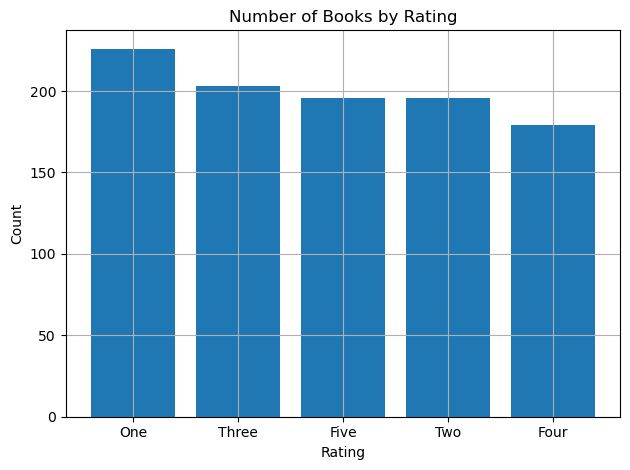

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Rating count
# df['Rating'].value_counts().plot(kind='bar')

rating_count = df['Rating'].value_counts()

x = rating_count.index
y = rating_count.values

plt.bar(x, y)
plt.title("Number of Books by Rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()  
plt.grid(True)
plt.show()

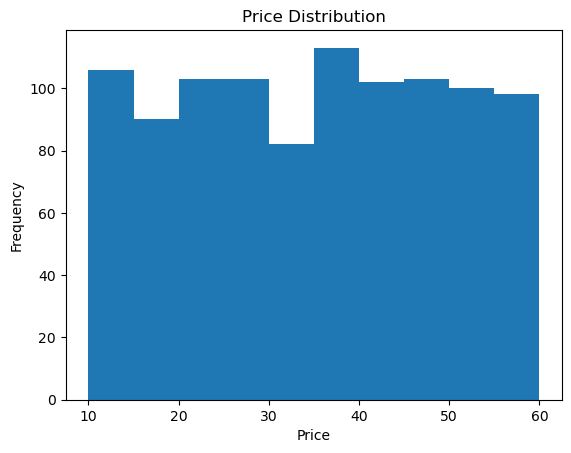

In [25]:
df['Price'].plot(kind='hist', bins=10)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

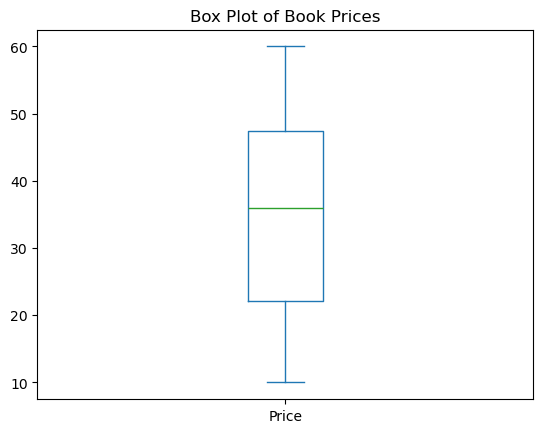

In [26]:
df['Price'].plot(kind='box')

plt.title("Box Plot of Book Prices")
plt.show()

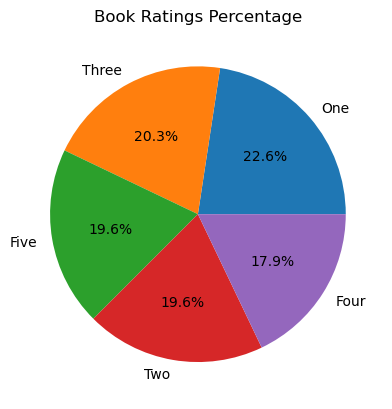

In [ ]:
df['Rating'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Book Ratings Percentage")
plt.ylabel("") 
plt.show()

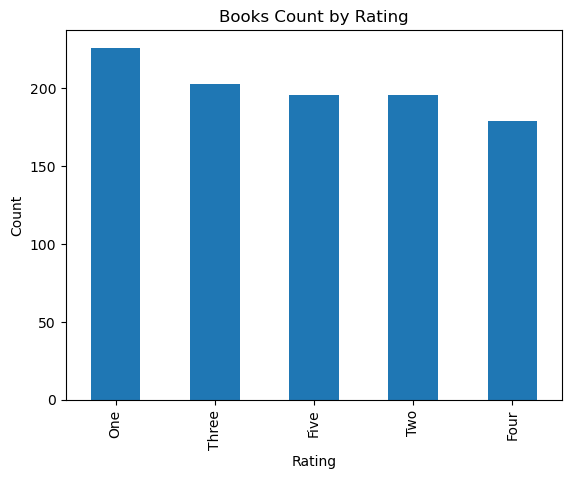

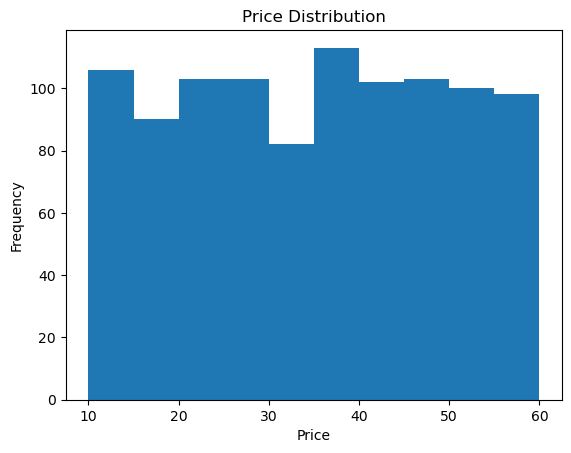

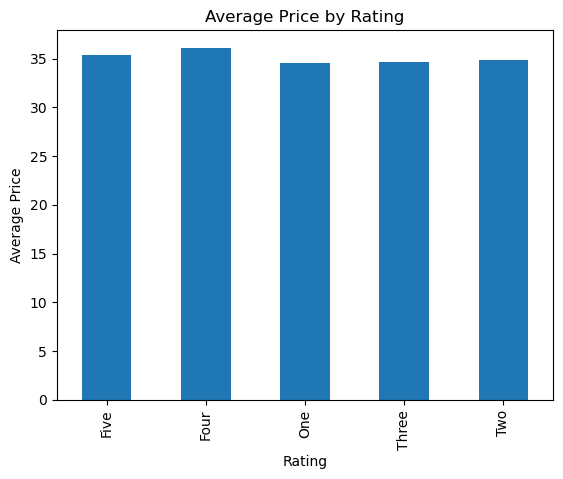

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# agar price string me ho
# df['Price'] = df['Price'].replace('£', '', regex=True).astype(float)

# 1. Rating count
df['Rating'].value_counts().plot(kind='bar')
plt.title("Books Count by Rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# 2. Price distribution
df['Price'].plot(kind='hist', bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

# 3. Average price by rating
df.groupby('Rating')['Price'].mean().plot(kind='bar')
plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.show()